# Project Title

**Team Members:** Abhishai Ganta, Anay Takkallapalli, Dhruv Sehgal

**Date:** Spring Quarter 2026

---

## Research Question
Can a reinforcement learning agent learn pitch sequencing policies that reduce expected run value compared to historical MLB pitch selection?

**Sub-questions:**
- RL vs MLB performance (run value)
- Effect of sequencing (prev pitch vs none)
- Key pitch sequences and their outcomes

**Expected Outcomes:**
- We expect reinforcement learning pitch sequencing to slightly outperform MLB strategies by reducing run value and using less predictable pitch patterns.

---

## Data Source

**Dataset Name:** pybaseball

**Link:** https://github.com/jldbc/pybaseball

**Description:**
- TODO: Briefly describe the dataset
- Number of observations: [TODO]
- Number of features: [TODO]
- Key variables: [TODO: List important columns]
- Time period covered: [TODO]
- Data collection method: [TODO]

**Citation:**
LeDoux, J. (2017, July 27). Introducing pybaseball: an Open Source Package for Baseball Data Analysis. https://jamesrledoux.com/projects/open-source/introducing-pybaseball/

---

## Setup and Imports

In [3]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install pybaseball
import sklearn
import scipy

# TODO: Add additional imports as needed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import pybaseball as pyb
from pybaseball import statcast
from sklearn.linear_model import LinearRegression
from sklearn.metrics import log_loss, accuracy_score


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# For reproducibility
np.random.seed(68)

print("Imports successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.8 MB/s eta 0:00:00
Imports successful!


---

## Data Loading

**TODO:** Load your dataset and perform initial inspection

In [4]:
# TODO: Load the dataset
# df = pd.read_csv('path/to/your/data.csv')
# df = pd.read_json('path/to/your/data.json')
# df = pd.read_excel('path/to/your/data.xlsx')

df = statcast(start_dt = '2024-03-03', end_dt = '2025-11-30')

# Display basic information
if df is not None:
    print(f"Dataset shape: {df.shape}")
    print(f"\nFirst few rows:")
    display(df.head())

This is a large query, it may take a moment to complete


/usr/local/lib/python3.12/dist-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates
Skipping offseason dates


  0%|          | 0/492 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = 

Dataset shape: (1531043, 118)

First few rows:


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
44,FS,2025-11-01,92.1,-2.02,5.15,"Yamamoto, Yoshinobu",672386,808967,grounded_into_double_play,hit_into_play,<NA>,<NA>,<NA>,<NA>,6,"Alejandro Kirk grounds into a double play, sho...",W,R,R,TOR,LAD,X,6,ground_ball,0,2,2025,-0.48,0.37,0.52943,2.165539,665489,<NA>,680718,1,11,Bot,119.57,155.13,<NA>,<NA>,<NA>,<NA>,7.524095,-133.878517,-2.517287,-7.425629,29.845675,-27.341263,3.13,1.5,5,71.9,-24,92.2,1320,6.5,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.03,0.03,0.029,0.0,1,0,0,2,99,3,Split-Finger,4,5,4,5,5,4,4,5,Standard,Standard,242,-0.36,-0.177,73.8,7.7,0.03,0.177,88.0,-1,-1,0.36,0.36,26,26,27,27,2,5,1,1,<NA>,<NA>,2.33,0.48,0.48,36.9,8.375233,-7.664043,17.979522,48.911447,37.014581
45,CU,2025-11-01,80.3,-1.7,5.45,"Yamamoto, Yoshinobu",672386,808967,NaN,called_strike,<NA>,<NA>,<NA>,<NA>,4,NaN,W,R,R,TOR,LAD,S,<NA>,NaN,0,1,2025,1.36,-1.25,-0.279088,1.962539,665489,<NA>,680718,1,11,Bot,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.56166,-116.768446,1.472301,12.095261,26.350181,-44.003006,2.915852,1.373793,<NA>,<NA>,<NA>,79.7,2970,6.4,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.15,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,99,2,Curveball,4,5,4,5,5,4,4,5,Standard,Standard,42,-0.066,-0.073,<NA>,<NA>,<NA>,0.073,<NA>,-1,-1,0.426,0.426,26,26,27,27,2,5,1,1,<NA>,<NA>,4.85,-1.36,-1.36,48.1,<NA>,<NA>,<NA>,<NA>,<NA>
51,FC,2025-11-01,92.8,-1.91,5.24,"Yamamoto, Yoshinobu",672386,808967,NaN,foul,<NA>,<NA>,<NA>,<NA>,9,NaN,W,R,R,TOR,LAD,S,<NA>,NaN,0,0,2025,0.23,0.6,0.564538,1.843233,665489,<NA>,680718,1,11,Bot,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5.856053,-135.072611,-4.233184,1.577981,29.102128,-24.072732,3.13,1.5,1,74.8,-53,93.2,2446,6.5,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.01,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,99,1,Cutter,4,5,4,5,5,4,4,5,Standard,Standard,187,-0.039,-0.041,73.0,7.5,<NA>,0.041,88.0,-1,-1,0.465,0.465,26,26,27,27,2,5,1,1,<NA>,<NA>,2.04,-0.23,-0.23,39.1,14.162806,5.694338,22.383742,47.652657,23.055298
55,FS,2025-11-01,90.9,-1.97,5.26,"Yamamoto, Yoshinobu",680718,808967,walk,blocked_ball,<NA>,<NA>,<NA>,<NA>,14,Addison Barger walks.,W,L,R,TOR,LAD,B,<NA>,NaN,3,0,2025,-0.69,0.02,0.473954,0.831956,665489,<NA>,<NA>,1,11,Bot,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7.631083,-132.145001,-5.243103,-9.709392,28.153507,-30.982919,3.764518,1.788782,<NA>,<NA>,<NA>,91.2,1523,6.5,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.0,<NA>,0.691497,0.7,1,0,0,<NA>,

In [5]:
# TODO: Examine dataset structure
if df is not None:
    print("Dataset Info:")
    df.info()

    print("\n" + "="*50)
    print("Summary Statistics:")
    display(df.describe())

    print("\n" + "="*50)
    print("Data Types:")
    display(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1531043 entries, 44 to 2068
Columns: 118 entries, pitch_type to intercept_ball_minus_batter_pos_y_inches
dtypes: Float64(42), Int64(59), datetime64[ns](1), object(16)
memory usage: 1.5+ GB

Summary Statistics:


,game_date,release_speed,release_pos_x,release_pos_z,batter,pitcher,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,hit_location,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
count,1531043,1495673.0,1495666.0,1495666.0,1531043.0,1531043.0,0.0,0.0,0.0,0.0,1495513.0,345813.0,1531043.0,1531043.0,1531043.0,1495532.0,1495665.0,1495513.0,1495513.0,145280.0,289314.0,466410.0,1531043.0,1531043.0,268812.0,268812.0,0.0,0.0,0.0,0.0,1495666.0,1495666.0,1495666.0,1495666.0,1495666.0,1495666.0,1495513.0,1495513.0,497684.0,497704.0,498447.0,1493965.0,1490370.0,1494475.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1495666.0,249150.0,369096.0,396186.0,372080.0,396186.0,396186.0,261062.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1490366.0,1531043.0,1525833.0,661416.0,661416.0,249150.0,1525833.0,500434.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1382087.0,1434235.0,1386824.0,1435078.0,1495527.0,1495532.0,1495532.0,1441885.0,661416.0,661416.0,661411.0,660642.0,660642.0
mean,2024-12-25 13:02:53.982572032,89.275026,-0.81677,5.764284,649265.934532,643649.848324,<NA>,<NA>,<NA>,<NA>,8.994159,5.127453,0.873422,0.899161,2024.503444,-0.115448,0.581678,0.04612,2.312829,651315.995416,650935.183112,649602.686317,0.981048,4.959658,126.509127,122.680157,<NA>,<NA>,<NA>,<NA>,2.432352,-129.839346,-3.693943,-2.225549,27.358065,-24.228226,3.415367,1.603069,157.140611,82.82709,17.623063,89.47722,2266.036138,6.440855,762477.007459,643392.947351,634878.825134,655429.983238,651776.245904,658981.582393,656229.0369,670546.929598,648869.79082,54.059108,0.322313,0.316104,0.321222,0.992483,0.188432,0.140633,3.222771,38.523189,2.90888,2.153603,2.293915,2.201967,2.245551,2.309073,2.168871,2.232393,2.245551,176.826385,0.000372,0.000217,69.566562,7.210684,0.544407,-0.000217,91.837752,-0.140312,-0.043584,0.50722,0.512902,28.924557,27.92211,29.444099,28.463963,1.470943,1.505743,5.999822,1.683092,6.108428,1.660133,2.328135,0.335228,-0.106278,37.896636,9.124841,-0.675029,32.273448,37.067715,29.888092
min,2024-03-15 00:00:00,21.7,-5.14,0.78,444482.0,434378.0,<NA>,<NA>,<NA>,<NA>,1.0,1.0,0.0,0.0,2024.0,-2.95,-2.45,-7.135099,-57.60148,444482.0,444482.0,444482.0,0.0,1.0,2.05,4.46,<NA>,<NA>,<NA>,<NA>,-19.976612,-153.07888,-29.291284,-32.368741,1.549108,-54.82463,2.506867,1.00017,0.0,2.6,-90.0,28.0,14.0,2.8,744795.0,455117.0,456781.0,456781.0,456781.0,462101.0,444482.0,453568.0,444482.0,50.88,0.001,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.822,-0.594,0.6,0.2,0.001,-2.696,88.0,-22.0,-22.0,0.0,0.001,19.0,17.0,20.0,18.0,1.0,0.0,0.0,0.0,0.0,0.0,0.27,-2.95,-2.95,-71.2,-89.556449,-179.835861,0.229517,5.494


Data Types:


,0
pitch_type,object
game_date,datetime64[ns]
release_speed,Float64
release_pos_x,Float64
release_pos_z,Float64
...,...
attack_angle,Float64
attack_direction,Float64
swing_path_tilt,Float64
intercept_ball_minus_batter_pos_x_inches,Float64


**Initial Observations:**

TODO: Document your first impressions of the data:
- Are there any obvious issues?
- Do the data types look correct?
- Are there missing values?
- Do the value ranges make sense?

---

## Data Cleaning

**TODO:** Clean and preprocess the data

### Missing Values Analysis

Missing Values Summary:


,Missing Count,Percentage
break_angle_deprecated,1531043,100.000000
break_length_deprecated,1531043,100.000000
spin_dir,1531043,100.000000
spin_rate_deprecated,1531043,100.000000
umpire,1531043,100.000000
sv_id,1531043,100.000000
tfs_deprecated,1531043,100.000000
tfs_zulu_deprecated,1531043,100.000000
on_3b,1385763,90.511044
estimated_ba_using_speedangle,1281893,83.726780


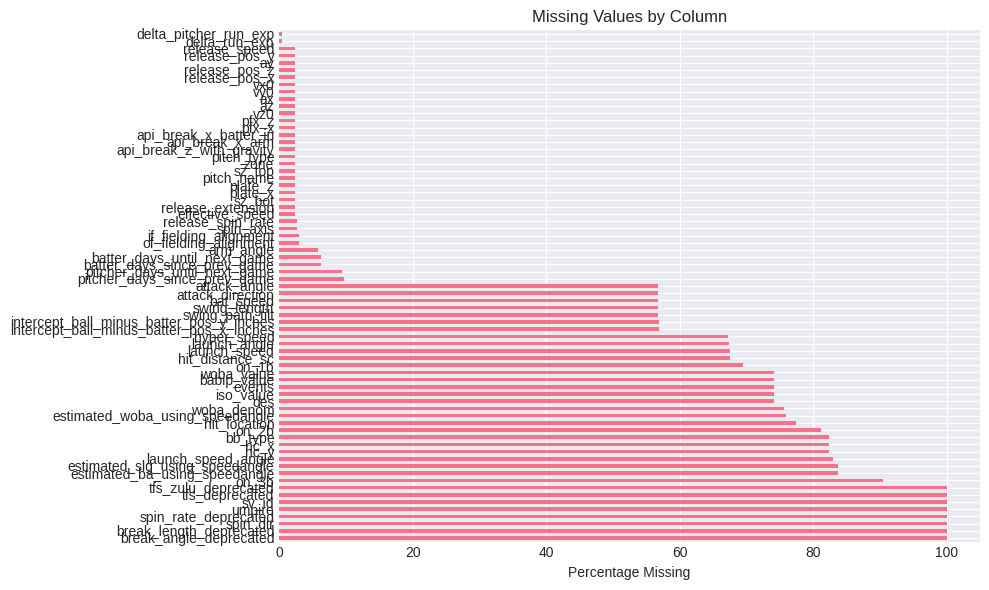

In [6]:
# TODO: Check for missing values
if df is not None:
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    }).sort_values('Percentage', ascending=False)

    print("Missing Values Summary:")
    display(missing_df[missing_df['Missing Count'] > 0])

    # Visualize missing data
    if missing.sum() > 0:
        plt.figure(figsize=(10, 6))
        missing_df[missing_df['Missing Count'] > 0]['Percentage'].plot(kind='barh')
        plt.xlabel('Percentage Missing')
        plt.title('Missing Values by Column')
        plt.tight_layout()
        plt.show()

In [ ]:
# TODO: Handle missing values
# Strategy options:
# 1. Drop rows: df = df.dropna()
# 2. Drop columns: df = df.drop(columns=['col_name'])
# 3. Fill with mean/median: df['col'] = df['col'].fillna(df['col'].mean())
# 4. Fill with mode: df['col'] = df['col'].fillna(df['col'].mode()[0])
# 5. Forward/backward fill: df = df.fillna(method='ffill')

# df_clean = df.copy()
# TODO: Implement your cleaning strategy here

### Duplicate Detection

In [7]:
# TODO: Check for duplicates
if df is not None:
    duplicates = df.duplicated().sum()
    print(f"Number of duplicate rows: {duplicates}")

    if duplicates > 0:
        print("\nDuplicate rows:")
        display(df[df.duplicated(keep=False)])

        # TODO: Decide whether to keep or remove duplicates
        # df_clean = df_clean.drop_duplicates()

Number of duplicate rows: 0


### Data Type Conversions

In [ ]:
# TODO: Convert data types as needed
# Examples:
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category_column'] = df_clean['category_column'].astype('category')
# df_clean['numeric_column'] = pd.to_numeric(df_clean['numeric_column'], errors='coerce')

pass

### Outlier Detection

In [ ]:
# TODO: Detect outliers in numeric columns
# Common methods:
# 1. IQR method
# 2. Z-score method
# 3. Visual inspection with box plots

# Example: Box plots for numeric columns
if df is not None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) > 0:
        # TODO: Create box plots for numeric columns
        # fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3*len(numeric_cols)))
        # for i, col in enumerate(numeric_cols):
        #     df.boxplot(column=col, ax=axes[i])
        # plt.tight_layout()
        # plt.show()
        pass

### Feature Engineering (Optional)

In [8]:
# RL-focused state features for pitch sequencing and MDP modeling
if df is not None:
    base_cols = [
        'game_date', 'game_pk', 'at_bat_number', 'pitch_number',
        'pitch_type', 'description', 'events',
        'balls', 'strikes', 'stand', 'p_throws',
        'plate_x', 'plate_z', 'release_speed',
        'release_pos_x', 'release_pos_z',
        'on_1b', 'on_2b', 'on_3b', 'delta_run_exp'
    ]
    selected_cols = [c for c in base_cols if c in df.columns]
    df_clean = df[selected_cols].copy()

    # Build a reliable at-bat identifier for grouping pitches
    if {'game_pk', 'at_bat_number'}.issubset(df_clean.columns):
        df_clean['at_bat_id'] = (
            df_clean['game_pk'].astype(str).fillna('') + '_' +
            df_clean['at_bat_number'].astype(str).fillna('')
        )
    else:
        df_clean['at_bat_id'] = (
            df_clean.get('game_pk', pd.Series([''] * len(df_clean))).astype(str).fillna('') + '_' +
            df_clean.get('batter', pd.Series([''] * len(df_clean))).astype(str).fillna('') + '_' +
            df_clean.get('pitcher', pd.Series([''] * len(df_clean))).astype(str).fillna('')
        )

    # Sort by at-bat and pitch order
    if 'pitch_number' in df_clean.columns:
        df_clean = df_clean.sort_values(['at_bat_id', 'pitch_number'], kind='stable')
    else:
        df_clean = df_clean.sort_values(['at_bat_id'], kind='stable')

    # Assign a sequential pitch_number within each at-bat if not already present
    if 'pitch_number' not in df_clean.columns:
        df_clean['pitch_number'] = df_clean.groupby('at_bat_id').cumcount() + 1

    # is_first_pitch: 1 if first pitch of the at-bat, 0 otherwise
    if {'balls', 'strikes'}.issubset(df_clean.columns):
        df_clean['is_first_pitch'] = (
            (df_clean['balls'].astype(int) == 0) &
            (df_clean['strikes'].astype(int) == 0)
        ).astype(int)
    else:
        df_clean['is_first_pitch'] = (df_clean['pitch_number'] == 1).astype(int)

    # Count state for MDP representation
    if {'balls', 'strikes'}.issubset(df_clean.columns):
        df_clean['balls'] = df_clean['balls'].astype(int)
        df_clean['strikes'] = df_clean['strikes'].astype(int)
        df_clean['count_state'] = df_clean['balls'].astype(str) + '-' + df_clean['strikes'].astype(str)
        df_clean['count_numeric'] = df_clean['balls'] * 10 + df_clean['strikes']

    # Base runner configuration — 0/1 integer flags + compact base_state bitmask
    if {'on_1b', 'on_2b', 'on_3b'}.issubset(df_clean.columns):
        df_clean[['on_1b', 'on_2b', 'on_3b']] = (
            df_clean[['on_1b', 'on_2b', 'on_3b']].fillna(0).astype(int)
        )
        df_clean['is_on_1b'] = (df_clean['on_1b'] > 0).astype(int)
        df_clean['is_on_2b'] = (df_clean['on_2b'] > 0).astype(int)
        df_clean['is_on_3b'] = (df_clean['on_3b'] > 0).astype(int)
        df_clean['base_state'] = (
            df_clean['is_on_1b'] * 1 +
            df_clean['is_on_2b'] * 2 +
            df_clean['is_on_3b'] * 4
        )

    # Batter and pitcher handedness
    if 'stand' in df_clean.columns:
        df_clean['batter_side'] = df_clean['stand'].fillna('U')
    if 'p_throws' in df_clean.columns:
        df_clean['pitcher_hand'] = df_clean['p_throws'].fillna('U')

    # Previous pitch features (shift within each at-bat)
    for col in ['pitch_type', 'description', 'events', 'delta_run_exp']:
        if col in df_clean.columns:
            df_clean[f'prev_{col}'] = df_clean.groupby('at_bat_id')[col].shift(1)

    # Strike zone location and zone label
    if {'plate_x', 'plate_z'}.issubset(df_clean.columns):
        df_clean['plate_x'] = pd.to_numeric(df_clean['plate_x'], errors='coerce')
        df_clean['plate_z'] = pd.to_numeric(df_clean['plate_z'], errors='coerce')
        df_clean['in_strike_zone'] = (
            (df_clean['plate_x'] >= -0.83) & (df_clean['plate_x'] <= 0.83) &
            (df_clean['plate_z'] >= 1.5)   & (df_clean['plate_z'] <= 3.5)
        ).fillna(False).astype(int)

        def plate_zone_label(x, z):
            if pd.isna(x) or pd.isna(z):
                return np.nan
            x_bin = int(np.clip(np.floor((x + 1.5) / 0.5), -3, 2))
            z_bin = int(np.clip(np.floor((z - 0.5) / 0.75), 0, 3))
            return f'{x_bin}_{z_bin}'

        df_clean['plate_zone'] = df_clean.apply(
            lambda row: plate_zone_label(row['plate_x'], row['plate_z']), axis=1
        )

    # Final column selection for MDP/RL model
    display_columns = [
        'at_bat_id', 'pitch_number', 'is_first_pitch',
        'balls', 'strikes', 'count_state', 'count_numeric',
        'base_state', 'is_on_1b', 'is_on_2b', 'is_on_3b',
        'batter_side', 'pitcher_hand',
        'pitch_type', 'description', 'events', 'delta_run_exp',
        'prev_pitch_type', 'prev_description', 'prev_events', 'prev_delta_run_exp',
        'plate_x', 'plate_z', 'in_strike_zone', 'plate_zone',
        'release_speed', 'release_pos_x', 'release_pos_z',
    ]
    display_columns = [c for c in display_columns if c in df_clean.columns]
    df_clean = df_clean[display_columns]

    df = df_clean
    print(f"Feature-engineered df shape: {df.shape}")
    print(f"\nColumn dtypes:\n{df.dtypes}")
    print(f"\nSample rows:")
    display(df.head(20))
else:
    print('Feature engineering skipped because df is None')

Feature-engineered df shape: (1531043, 28)

Column dtypes:
at_bat_id              object
pitch_number            Int64
is_first_pitch          int64
balls                   int64
strikes                 int64
count_state            object
count_numeric           int64
base_state              int64
is_on_1b                int64
is_on_2b                int64
is_on_3b                int64
batter_side            object
pitcher_hand           object
pitch_type             object
description            object
events                 object
delta_run_exp         Float64
prev_pitch_type        object
prev_description       object
prev_events            object
prev_delta_run_exp    Float64
plate_x               Float64
plate_z               Float64
in_strike_zone          int64
plate_zone             object
release_speed         Float64
release_pos_x         Float64
release_pos_z         Float64
dtype: object

Sample rows:


,at_bat_id,pitch_number,is_first_pitch,balls,strikes,count_state,count_numeric,base_state,is_on_1b,is_on_2b,is_on_3b,batter_side,pitcher_hand,pitch_type,description,events,delta_run_exp,prev_pitch_type,prev_description,prev_events,prev_delta_run_exp,plate_x,plate_z,in_strike_zone,plate_zone,release_speed,release_pos_x,release_pos_z
4022,744795_1,1,1,0,0,0-0,0,0,0,0,0,R,L,FF,foul,NaN,-0.037,NaN,NaN,NaN,<NA>,0.439332,3.164778,1,2_3,91.9,1.76,5.8
3915,744795_1,2,0,0,1,0-1,1,0,0,0,0,R,L,CH,ball,NaN,0.025,FF,foul,NaN,-0.037,1.078188,3.661966,0,2_3,81.1,2.05,5.66
3774,744795_1,3,0,1,1,1-1,11,0,0,0,0,R,L,CH,ball,NaN,0.053,CH,ball,NaN,0.025,0.38592,3.674862,0,2_3,80.8,2.01,5.69
3691,744795_1,4,0,2,1,2-1,21,0,0,0,0,R,L,FF,ball,NaN,0.122,CH,ball,NaN,0.053,1.203936,1.704576,0,2_1,92.0,1.8,5.77
3534,744795_1,5,0,3,1,3-1,31,0,0,0,0,R,L,FF,called_strike,NaN,-0.085,FF,ball,NaN,0.122,0.685685,1.867021,1,2_1,93.7,1.88,5.72
3373,744795_1,6,0,3,2,3-2,32,0,0,0,0,R,L,FF,foul,NaN,0.0,FF,called_strike,NaN,-0.085,0.612603,2.844439,1,2_3,92.9,1.96,5.7
3215,744795_1,7,0,3,2,3-2,32,0,0,0,0,R,L,SL,hit_into_play,field_out,-0.333,FF,foul,NaN,0.0,0.057643,3.479877,1,2_3,85.2,2.0,5.65
1725,744795_10,1,1,0,0,0-0,0,1,1,0,0,L,L,FF,hit_into_play,field_out,-0.255,NaN,NaN,NaN,<NA>,0.531977,2.157946,1,2_2,92.1,2.01,5.92
1650,744795_11,1,1,0,0,0-0,0,1,1,0,0,R,L,FF,ball,NaN,0.034,NaN,NaN,NaN,<NA>,1.542031,4.090136,0,2_3,91.1,1.89,5.99
1622,744795_11,2,0,1,0,1-0,10,1,1,0,0,R,L,FF,called_strike,NaN,-0.048,FF,ball,NaN,0.034,-0.355407,2.104395,1,2_2,91.5,1.98,5.99


In [ ]:
# TODO: Save cleaned dataset (optional)
# df_clean.to_csv('data/cleaned_data.csv', index=False)
# print("Cleaned data saved!")

**Cleaning Summary:**

TODO: Document what cleaning steps were performed and why:
- Missing values: [strategy used]
- Duplicates: [action taken]
- Outliers: [how handled]
- Feature engineering: [new features created]

---

## Exploratory Data Analysis

**TODO:** Explore the data to understand patterns, relationships, and distributions

Graphs

### Bivariate Analysis

### Bivariate Analysis

<Axes: xlabel='count_state', ylabel='count'>

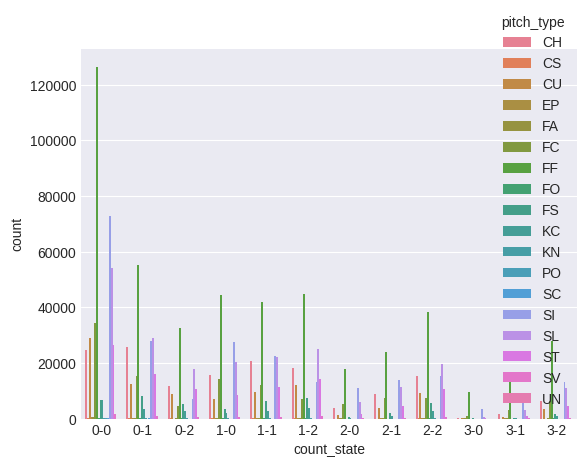

In [9]:
pitch_by_count = df.groupby(['count_state', 'pitch_type']).size().reset_index(name='count')
sns.barplot(data=pitch_by_count, x='count_state', y='count', hue='pitch_type')

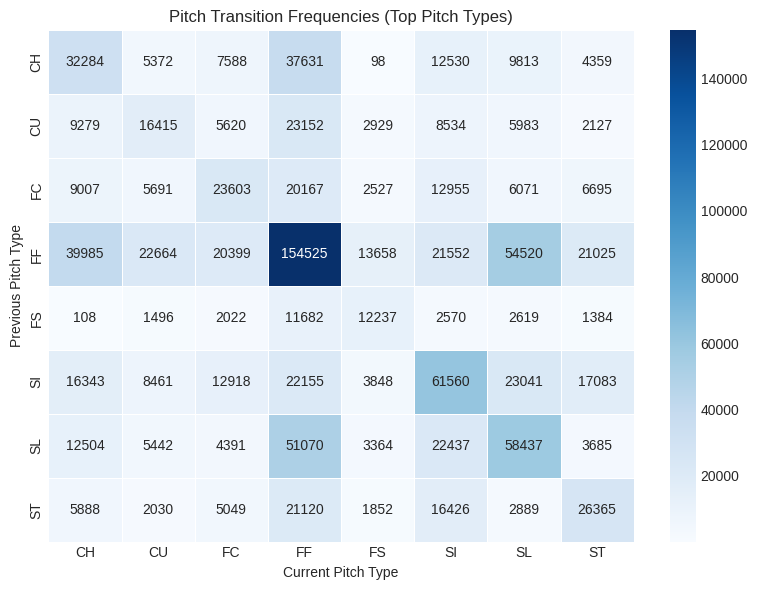

In [11]:
# top 8 most common pitch types
top_pitches = df['pitch_type'].value_counts().head(8).index

filtered = df[
    df['pitch_type'].isin(top_pitches) &
    df['prev_pitch_type'].isin(top_pitches)
]

transition = pd.crosstab(filtered['prev_pitch_type'], filtered['pitch_type'])

plt.figure(figsize=(8, 6))
sns.heatmap(
    transition,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Pitch Transition Frequencies (Top Pitch Types)')
plt.xlabel('Current Pitch Type')
plt.ylabel('Previous Pitch Type')
plt.tight_layout()
plt.show()

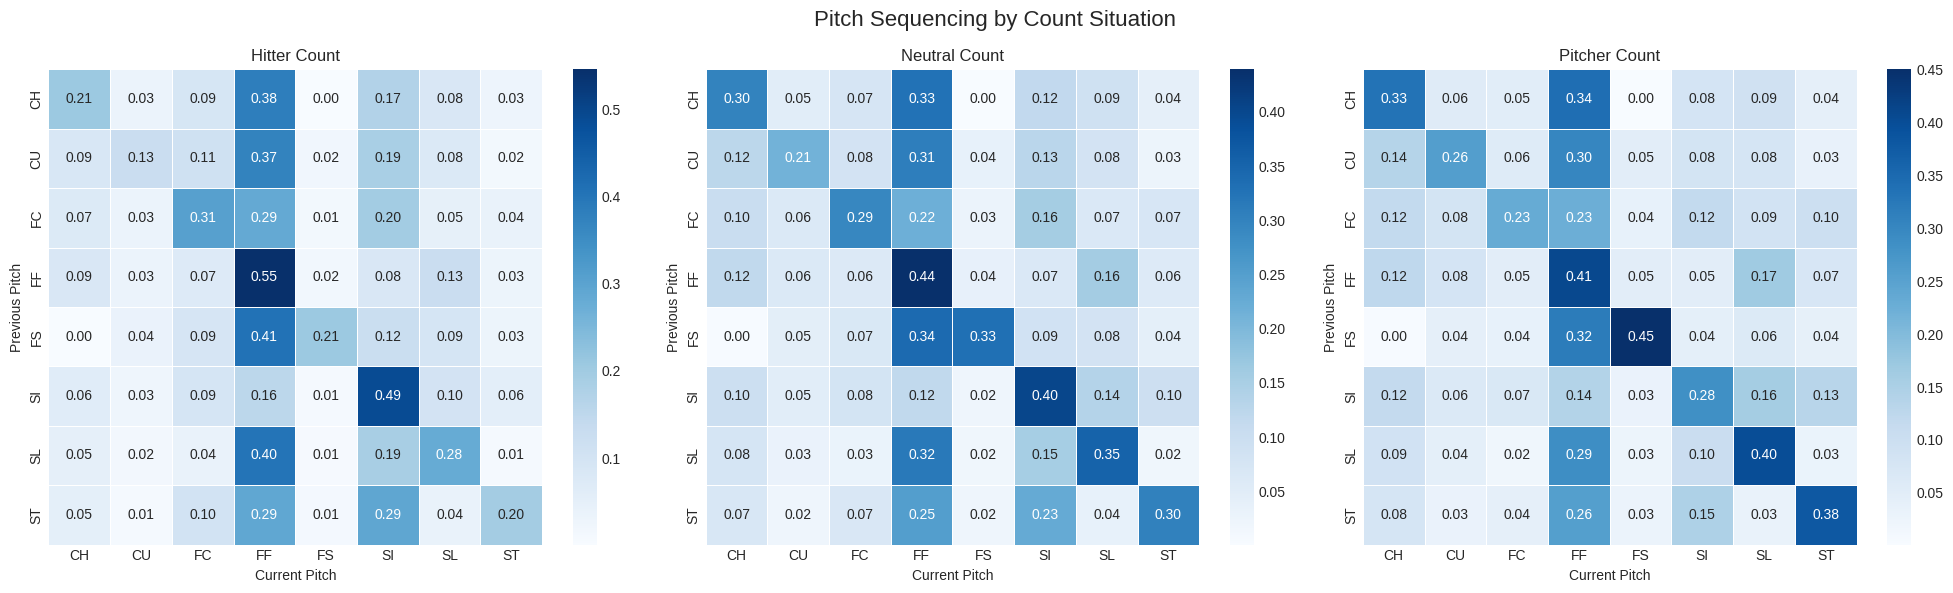

In [14]:
def count_group(count):
    if count in ['2-0', '3-0', '3-1', '2-1']:
        return 'Hitter Count'
    elif count in ['0-2', '1-2', '0-1']:
        return 'Pitcher Count'
    else:
        return 'Neutral Count'

df['count_group'] = df['count_state'].apply(count_group)

# top pitch types
top_pitches = df['pitch_type'].value_counts().head(8).index

filtered = df[
    df['pitch_type'].isin(top_pitches) &
    df['prev_pitch_type'].isin(top_pitches) &
    df['prev_pitch_type'].notna()
]

groups = ['Hitter Count', 'Neutral Count', 'Pitcher Count']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, group in zip(axes, groups):
    subset = filtered[filtered['count_group'] == group]

    if subset.empty:
        ax.set_title(f'{group}\n(No Data)')
        ax.axis('off')
        continue

    transition = pd.crosstab(
        subset['prev_pitch_type'],
        subset['pitch_type'],
        normalize='index'
    )

    sns.heatmap(
        transition,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(group)
    ax.set_xlabel('Current Pitch')
    ax.set_ylabel('Previous Pitch')

plt.suptitle('Pitch Sequencing by Count Situation', fontsize=16)
plt.tight_layout()
plt.show()

<Axes: xlabel='pitch_type', ylabel='delta_run_exp'>

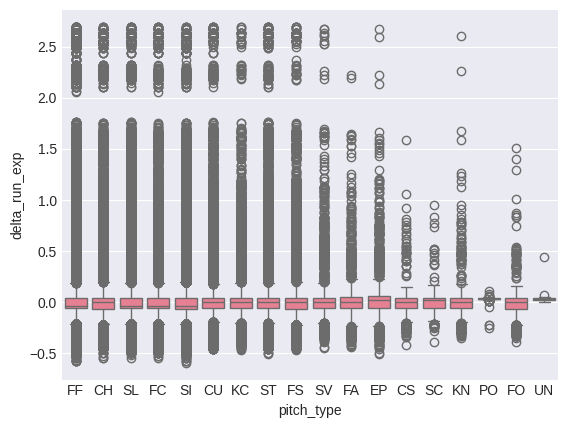

In [20]:
df = df.reset_index(drop=True)
sns.boxplot(data=df, x='pitch_type', y='delta_run_exp')

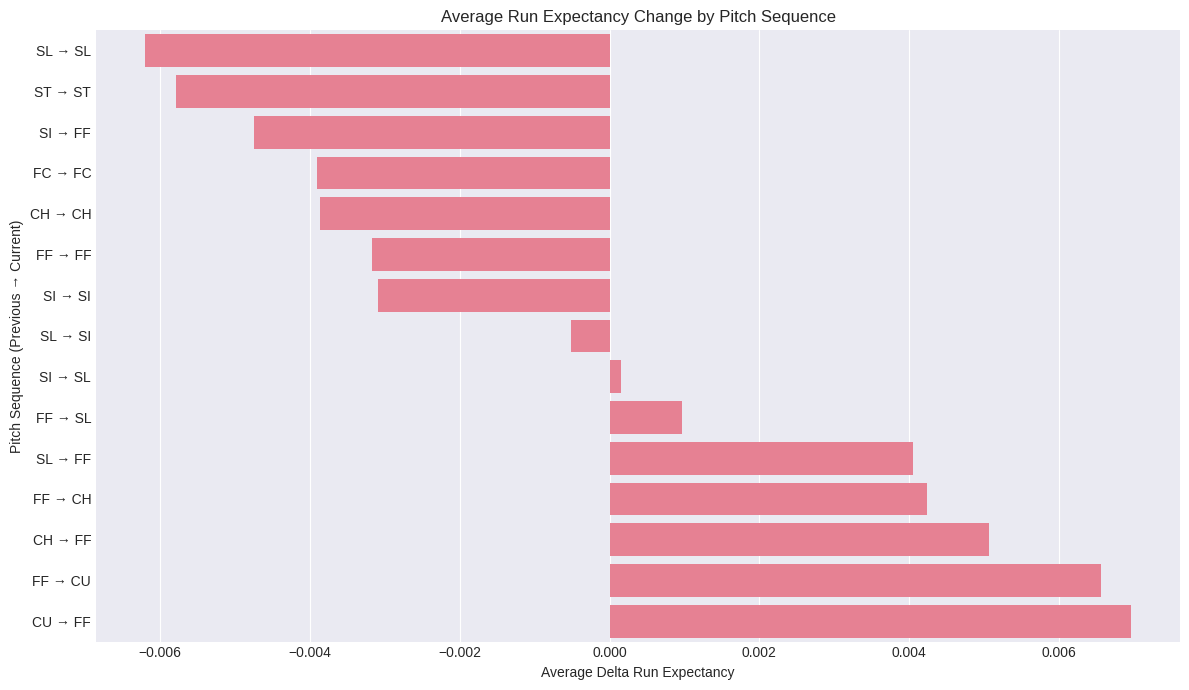

In [21]:

# remove missing values
plot_df = df[
    df['prev_pitch_type'].notna() &
    df['pitch_type'].notna() &
    df['delta_run_exp'].notna()
].copy()

# create sequence label
plot_df['sequence'] = plot_df['prev_pitch_type'] + ' → ' + plot_df['pitch_type']

# top 15 most common sequences
top_sequences = plot_df['sequence'].value_counts().head(15).index

plot_df = plot_df[plot_df['sequence'].isin(top_sequences)]

# average run expectancy change
avg_seq = (
    plot_df.groupby('sequence')['delta_run_exp']
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=avg_seq,
    x='delta_run_exp',
    y='sequence'
)

plt.title('Average Run Expectancy Change by Pitch Sequence')
plt.xlabel('Average Delta Run Expectancy')
plt.ylabel('Pitch Sequence (Previous → Current)')
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Explore relationships among multiple variables

# Pair plot for selected variables
# if df_clean is not None:
#     # Select key columns for pair plot
#     # key_cols = ['col1', 'col2', 'col3', 'target']
#     # sns.pairplot(df_clean[key_cols], hue='target')
#     # plt.show()

    pass

**EDA Findings:**

TODO: Summarize key insights from your exploratory analysis:
- What are the main patterns in the data?
- Are there any unexpected findings?
- Which variables seem most relevant to your research question?
- Are there any data quality issues that need addressing?

---

## Modeling and Analysis

**TODO:** Build and evaluate models to answer your research question

### Data Preparation for Modeling

In [ ]:
# TODO: Prepare data for modeling
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder

# Define features and target
# X = df_clean[['feature1', 'feature2', 'feature3']]
# y = df_clean['target']

# Split data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# Scale features (if needed)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

pass

### Model 1: [Model Name]

**TODO:** Describe the model and why you chose it

In [ ]:
# TODO: Train your first model
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# model = LogisticRegression(random_state=42)
# model.fit(X_train_scaled, y_train)

pass

In [ ]:
# TODO: Make predictions and evaluate
# y_pred = model.predict(X_test_scaled)

# print("Model Performance:")
# print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix')
# plt.ylabel('True Label')
# plt.xlabel('Predicted Label')
# plt.show()

pass

### Model 2: [Model Name]

**TODO:** Describe your second model approach

In [ ]:
# TODO: Train and evaluate second model

pass

### Model Comparison

In [ ]:
# TODO: Compare model performance
# Create a comparison table or visualization

# results_df = pd.DataFrame({
#     'Model': ['Model 1', 'Model 2'],
#     'Accuracy': [acc1, acc2],
#     'Precision': [prec1, prec2],
#     'Recall': [rec1, rec2],
#     'F1-Score': [f1_1, f1_2]
# })
# display(results_df)

pass

### Feature Importance (Optional)

In [ ]:
# TODO: Analyze feature importance (if applicable)
# if hasattr(model, 'feature_importances_'):
#     importance_df = pd.DataFrame({
#         'Feature': X.columns,
#         'Importance': model.feature_importances_
#     }).sort_values('Importance', ascending=False)
#
#     plt.figure(figsize=(10, 6))
#     plt.barh(importance_df['Feature'], importance_df['Importance'])
#     plt.xlabel('Importance')
#     plt.title('Feature Importance')
#     plt.gca().invert_yaxis()
#     plt.tight_layout()
#     plt.show()

pass

**Modeling Results:**

TODO: Summarize your modeling findings:
- Which model performed best and why?
- What are the most important predictors?
- Are there any limitations or concerns with the models?
- Do the results answer your research question?

---

## Conclusions and Future Work

**TODO:** Summarize your project and findings

### Key Findings

TODO: List your main discoveries:
1.
2.
3.

### Limitations

TODO: What are the limitations of this analysis?
-
-

### Future Work

TODO: What could be done to extend or improve this analysis?
-
-

### Recommendations

TODO: Based on your findings, what actions or decisions do you recommend?
-
-

---

## References

TODO: List all data sources, papers, and resources used:

1.
2.
3.